<a href="https://colab.research.google.com/github/AngelosDid/Region-CellSegmentation/blob/main/notebooks/train_Cellpose-SAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Cellpose-SAM: superhuman generalization for cellular segmentation

Marius Pachitariu, Michael Rariden, Carsen Stringer

[paper](https://www.biorxiv.org/content/10.1101/2025.04.28.651001v1) | [code](https://github.com/MouseLand/cellpose)

This notebook shows how to process your own 2D or 3D images, saved on Google Drive.

This notebook is adapted from the notebook by Pradeep Rajasekhar, inspired by the [ZeroCostDL4Mic notebook series](https://github.com/HenriquesLab/ZeroCostDL4Mic/wiki).

### Make sure you have GPU access enabled by going to Runtime -> Change Runtime Type -> Hardware accelerator and selecting GPU

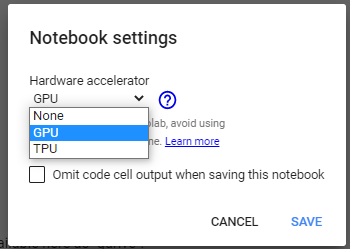

### Mount your google drive

If you have some images to train on, mount your drive. Alternatively scroll down and download the example images.

Run this cell to connect your Google Drive to colab:
* Click on the URL.
* Sign in your Google Account.

You will either have to:
* copy the authorisation code and enter it into box below OR
* in the new google colab, you can just click "Allow" and it should connect.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



Then click on "Folder" icon on the Left, press the refresh button. Your Google Drive folder should now be available here as "gdrive".


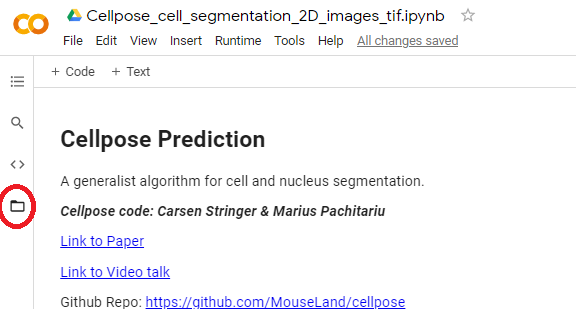

Click on the triangle icon and it will allow you to access whole drive. Navigate to the folder containing your images. Once you are there, click on the three dots on the right of the folder and select "Copy Path"

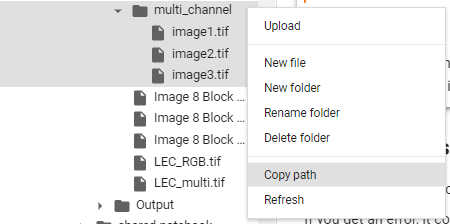

Copy and paste this path in the **dir** string below

### Install Cellpose-SAM


In [2]:
!pip install git+https://www.github.com/mouseland/cellpose.git

  Cloning https://www.github.com/mouseland/cellpose.git to /tmp/pip-req-build-vmv3xe_b
  Running command git clone --filter=blob:none --quiet https://www.github.com/mouseland/cellpose.git /tmp/pip-req-build-vmv3xe_b
  Resolved https://www.github.com/mouseland/cellpose.git to commit 4fbdc7cc5ec34c38c14258ac0e869a6bd802f3ca
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 101.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 94.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 113.2 MB/s eta 0:00:00
  Created wheel for cellpose: filename=cellpose-4.0.9.dev7+g4fbdc7cc5-py3-none-any.whl size=212309 sha256=b424bc8a6c7d9548f114015e122bb0d7e2ec8bcec81603d48202701f8e56b30a
  Stored in directory: /tmp/pip-ephem-wheel-cache-9e06u8sv/wheels/df/b6/31/a3013c44290eabb46f4c06d1efb19744124fcad2d59684ec5e
Successfully built cellpose


Check GPU and instantiate model - will download weights.

In [3]:
import numpy as np
from cellpose import models, core, io, plot
from pathlib import Path
from tqdm import trange
import matplotlib.pyplot as plt

io.logger_setup() # run this to get printing of progress

#Check if colab notebook instance has GPU access
if core.use_gpu()==False:
  raise ImportError("No GPU access, change your runtime")

model = models.CellposeModel(gpu=True)

creating new log file
2026-02-25 16:18:09,357 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-02-25 16:18:09,357 [INFO] 
cellpose version: 	4.0.9.dev7+g4fbdc7cc5 
platform:       	linux 
python version: 	3.12.12 
torch version:  	2.10.0+cu128
2026-02-25 16:18:09,846 [INFO] ** TORCH CUDA version installed and working. **
2026-02-25 16:18:09,847 [INFO] ** TORCH CUDA version installed and working. **
2026-02-25 16:18:09,848 [INFO] >>>> using GPU (CUDA)
2026-02-25 16:18:12,342 [INFO] Downloading: "https://huggingface.co/mouseland/cellpose-sam/resolve/main/cpsam" to /root/.cellpose/models/cpsam



100%|██████████| 1.15G/1.15G [00:08<00:00, 138MB/s]


Input directory with your images (if you have them, otherwise use sample images):

plot masks

# Run Predictions

#### Run Predictions with new data

2026-02-25 16:34:57,192 [INFO] ** TORCH CUDA version installed and working. **
2026-02-25 16:34:57,193 [INFO] >>>> using GPU (CUDA)
2026-02-25 16:34:59,531 [INFO] >>>> loading model /content/drive/MyDrive/models/cfos_model
2026-02-25 16:35:00,188 [INFO] 0%|          | 0/8 [00:00<?, ?it/s]
2026-02-25 16:35:00,636 [INFO] processing image with (8430, 8404) HW, and 3 channels
2026-02-25 16:35:42,665 [INFO] 12%|#2        | 1/8 [00:42<04:57, 42.48s/it]
2026-02-25 16:35:43,112 [INFO] processing image with (8430, 8404) HW, and 3 channels
2026-02-25 16:36:23,450 [INFO] 25%|##5       | 2/8 [01:23<04:08, 41.48s/it]
2026-02-25 16:36:23,897 [INFO] processing image with (8430, 8404) HW, and 3 channels
2026-02-25 16:37:04,352 [INFO] 38%|###7      | 3/8 [02:04<03:26, 41.22s/it]
2026-02-25 16:37:04,802 [INFO] processing image with (8430, 8404) HW, and 3 channels
2026-02-25 16:37:51,700 [INFO] 50%|#####     | 4/8 [02:51<02:54, 43.64s/it]
2026-02-25 16:37:52,148 [INFO] processing image with (8430, 8404) 

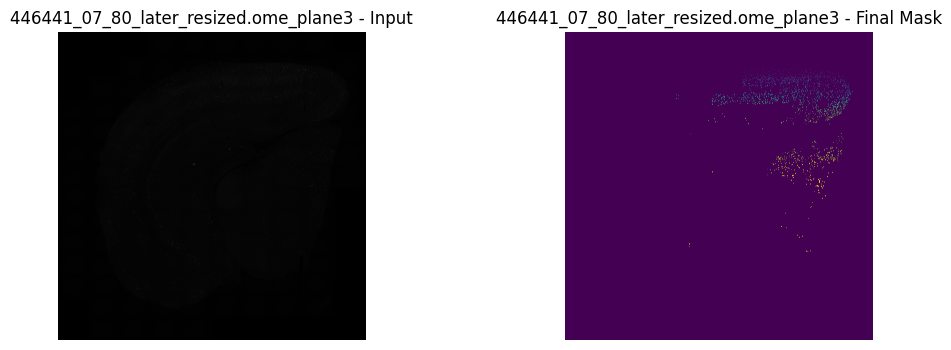

446441_07_80_later_resized.ome_plane3: 2323 ROIs kept


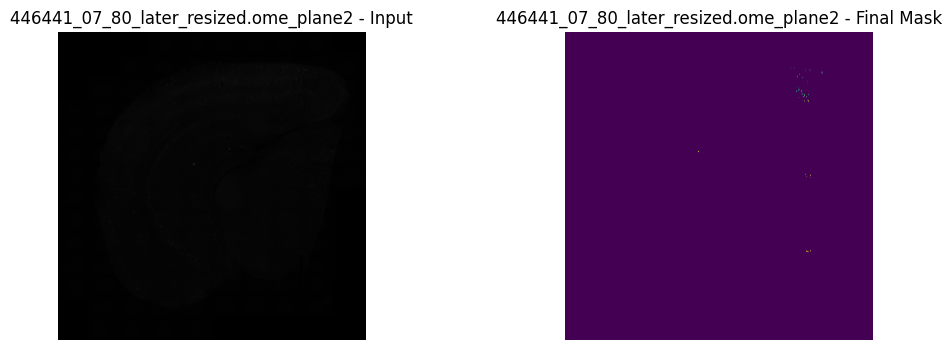

446441_07_80_later_resized.ome_plane2: 65 ROIs kept


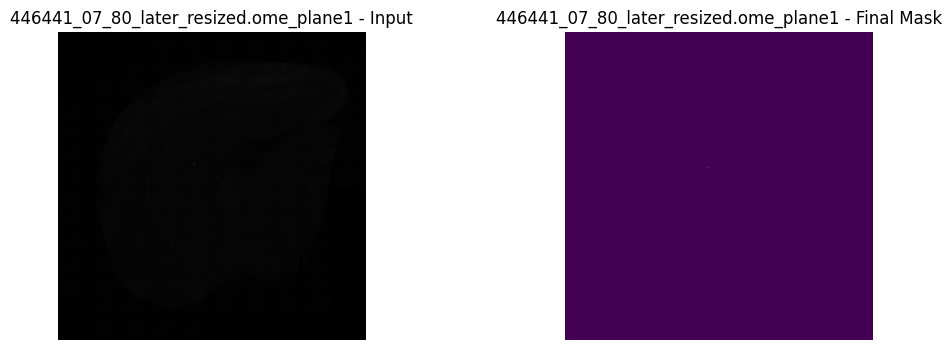

446441_07_80_later_resized.ome_plane1: 2 ROIs kept


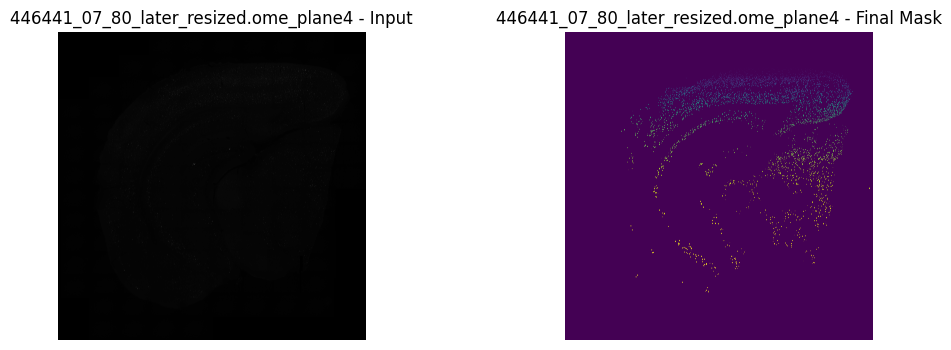

446441_07_80_later_resized.ome_plane4: 5603 ROIs kept


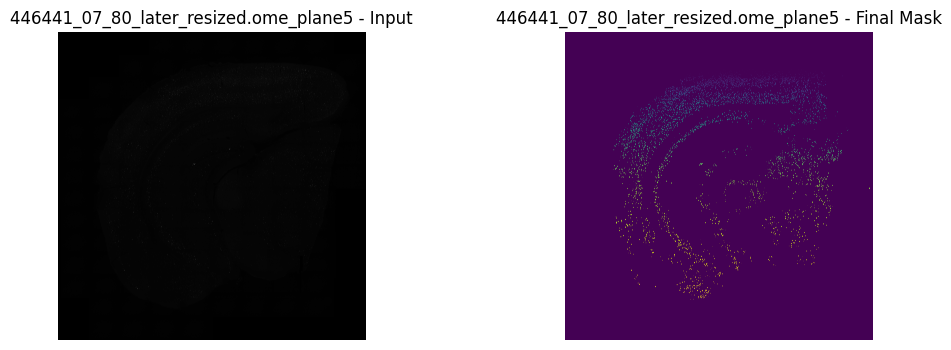

446441_07_80_later_resized.ome_plane5: 5914 ROIs kept


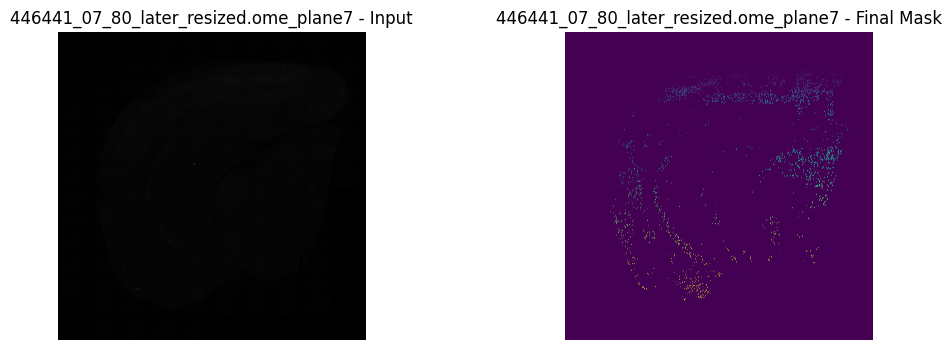

446441_07_80_later_resized.ome_plane7: 2162 ROIs kept


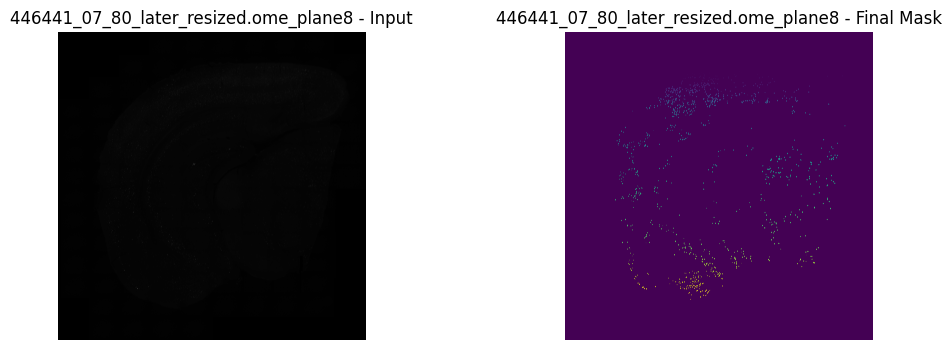

446441_07_80_later_resized.ome_plane8: 1061 ROIs kept


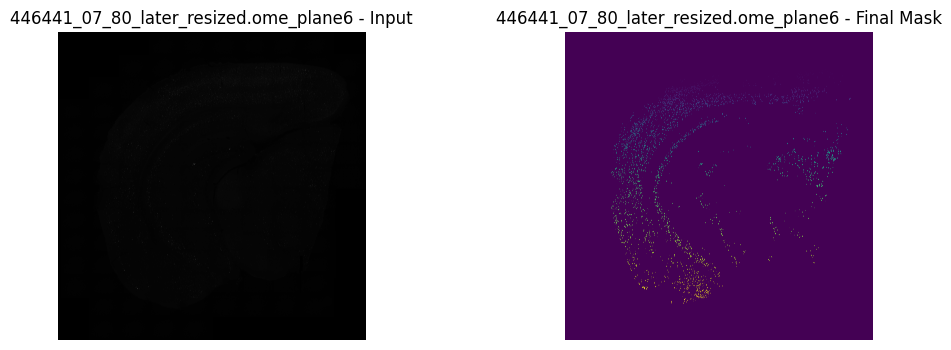

446441_07_80_later_resized.ome_plane6: 3655 ROIs kept


In [5]:
# N E W   C O D E     F E B R U A R Y   2 0 2 6

# Inserted minimum pixel size for detection -> min_size_px
# Defined a maximum pixel size as 3 times larger than the average size of all ROIs (if the average is too high, then average becomes artificially 300 pixels)
# Used CHATGPT to insert some code to get rid of 'pixel islands' because they later on create inconsistencies in labelling (e.g. 001_1010-1, 001_1010-2,  instead of 001_1010, 001_1011).
# Inserted a line to create a single label, top left at the image in case that no labels are detected.
# Caution : connectivity here is 8, which means that the label to ROIs command in fiji must have a c8 and not c4 !

from cellpose import models
import tifffile
import os
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from skimage.measure import label

# === CONFIG ===
model_path = '/content/drive/MyDrive/models/cfos_model'
image_dir = '/content/drive/MyDrive/Colab Notebooks/tests'
output_mask_dir = '/content/drive/MyDrive/Colab Notebooks/outputs/original'
os.makedirs(output_mask_dir, exist_ok=True)

min_size_px = 25  # minimum ROI size in pixels

# Load images
image_paths = list(Path(image_dir).glob("*.tif*"))
if not image_paths:
    raise FileNotFoundError(f"No .tif files found in {image_dir}")

imgs = []
names = []
for path in image_paths:
    img = tifffile.imread(str(path))
    if img.ndim == 2:
        img = img[np.newaxis, ...]
    elif img.ndim == 3 and img.shape[0] not in [1, 3]:
        img = img.transpose(2, 0, 1)
    imgs.append(img.astype(np.float32))
    names.append(path.stem)

# Load Cellpose model
model = models.CellposeModel(gpu=True, pretrained_model=model_path)

# Run model
masks_list, _, _ = model.eval(
    imgs,
    batch_size=64,
    resample=True,
    cellprob_threshold=-1,
    min_size=min_size_px
)

# =========================
# POST-PROCESSING LOOP
# =========================
for img_array, name, mask in zip(imgs, names, masks_list):

    # -------------------------
    # 1️⃣ Filter by original label size
    # -------------------------
    flat_mask = mask.ravel()
    label_counts = np.bincount(flat_mask)
    label_counts[0] = 0

    if len(label_counts) > 1:

        areas = label_counts[label_counts > 0]
        avg_area = np.mean(areas)

        if avg_area > 600:
            avg_area = 300

        max_area = 3 * avg_area

        keep_labels = (
            (label_counts >= min_size_px) &
            (label_counts <= max_area)
        )
        keep_labels[0] = False

        surviving_labels = np.where(keep_labels)[0]

        # Remap old labels → temporary consecutive labels
        new_ids = np.zeros_like(label_counts, dtype=np.uint16)
        new_ids[surviving_labels] = np.arange(
            1,
            len(surviving_labels) + 1,
            dtype=np.uint16
        )

        filtered_mask = new_ids[mask]

        # -------------------------
        # 2️⃣ Split disconnected islands
        # -------------------------
        filtered_mask = label(filtered_mask).astype(np.uint16)

        # -------------------------
        # 3️⃣ Remove small fragments AFTER splitting
        # -------------------------
        flat2 = filtered_mask.ravel()
        counts2 = np.bincount(flat2)
        counts2[0] = 0

        keep2 = counts2 >= min_size_px
        keep2[0] = False

        filtered_mask = keep2[filtered_mask] * filtered_mask

        # -------------------------
        # 4️⃣ Final consecutive relabel
        # -------------------------
        filtered_mask = label(filtered_mask).astype(np.uint16)

    else:
        filtered_mask = mask.astype(np.uint16)

    # If no labels are detected, create a small label at left edge of the image to prevent errors while using AResCoN. We need at least one label.
    if filtered_mask.max() == 0: filtered_mask.flat[:min_size_px + 1] = 1
    # Save mask
    out_path = os.path.join(output_mask_dir, name + '_filtered_mask.tiff')
    tifffile.imwrite(out_path, filtered_mask.astype(np.uint16))

    # Optional visualization
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img_array[0], cmap='gray')
    plt.title(f'{name} - Input')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(filtered_mask)
    plt.title(f'{name} - Final Mask')
    plt.axis('off')

    plt.show()

    print(f"{name}: {filtered_mask.max()} ROIs kept")

In [ ]:
# from cellpose import utils, models
# import tifffile
# import os
# import matplotlib.pyplot as plt
# import numpy as np
# from pathlib import Path

# # === CONFIG ===
# model_path = '/content/drive/MyDrive/models/cfos_model'
# image_dir = '/content/drive/MyDrive/Colab Notebooks/tests/bs127hist1024max6'
# output_mask_dir = '/content/drive/MyDrive/Colab Notebooks/outputs/bs127hist1024max6'
# os.makedirs(output_mask_dir, exist_ok=True)

# # Load your .tif images
# image_paths = list(Path(image_dir).glob("*.tif"))
# if not image_paths:
#     raise FileNotFoundError(f"No .tif files found in {image_dir}")

# # Load model
# model = models.CellposeModel(gpu=True, pretrained_model=model_path)

# # Preprocess all images
# imgs = []
# names = []
# for path in image_paths:
#     img = tifffile.imread(str(path))
#     if img.ndim == 2:
#         img = img[np.newaxis, ...]  # shape (1, H, W)
#     elif img.ndim == 3 and img.shape[0] not in [1, 3]:
#         img = img.transpose(2, 0, 1)  # shape (channels, H, W)
#     imgs.append(img.astype(np.float32))
#     names.append(path.stem)

# # Run model on all images at once (batched)
# masks_list, _, _ = model.eval(
#     imgs,
#     batch_size=64,  # adjust based on your GPU memory
#     resample=True,
#     cellprob_threshold=-1
# )

# # Save predictions
# for name, mask in zip(names, masks_list):
#     out_path = os.path.join(output_mask_dir, name + '_predicted_mask.tiff')
#     tifffile.imwrite(out_path, mask.astype(np.uint16))

#     # Optional: show prediction
#     plt.figure(figsize=(12, 4))
#     plt.subplot(1, 2, 1)
#     plt.imshow(imgs[0][0], cmap='gray')  # show first channel
#     plt.title(f'{name} - Input')
#     plt.axis('off')

#     plt.subplot(1, 2, 2)
#     plt.imshow(mask)
#     plt.title(f'{name} - Predicted Mask')
#     plt.axis('off')
#     plt.show()
